# BB84 Quantum Key Distribution Protocol

Generated from the public notebook builder for reproducible analysis.

The BB84 protocol (Bennett & Brassard, 1984) lets two parties â€” Alice and Bob â€” establish a shared secret key over an insecure quantum channel. This notebook runs an **ideal-channel** simulation (no eavesdropper, no fiber loss) using the seven `src/bb84.py` functions built in Notebook 01.

## Protocol pipeline

1. **Preparation** &mdash; Alice randomly chooses a bit and a basis, encoding it into one of $\{|0\rangle, |1\rangle, |+\rangle, |-\rangle\}$.
2. **Transmission** &mdash; Single photons travel to Bob.
3. **Measurement** &mdash; Bob picks a random basis. Same basis as Alice $\Rightarrow$ deterministic; mismatched basis $\Rightarrow$ uniform 50/50 (Born rule).
4. **Sifting** &mdash; Alice and Bob publicly compare *bases* (not bit values). Mismatched rounds are dropped.
5. **QBER estimation** &mdash; A random subset of sifted bits is disclosed to estimate the error rate. The disclosed sample is permanently removed.
6. **Error correction** &mdash; A perfect-reconciliation stub leaks $f_{ec} \, n \, h(\mathrm{QBER})$ bits to Eve.
7. **Privacy amplification** &mdash; Universal$_2$ hashing yields a final key of length $L = N_{\text{remaining}} \, \max(0, 1 - h(\mathrm{QBER}) - f_{ec} \, h(\mathrm{QBER}))$.


## 1. Bootstrap and imports

The bootstrap cell finds the project root from the notebook's CWD, appends it to `sys.path`, and creates the `figures/` directory.

In [1]:
from pathlib import Path
import sys


def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'src').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise RuntimeError('Could not find project root')


PROJECT_ROOT = find_project_root()
FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')
print(f'Figure dir : {FIG_DIR}')


Project root: C:\Users\COWLAR\projects\qkd-protocol-simulator
Figure dir : C:\Users\COWLAR\projects\qkd-protocol-simulator\figures


In [2]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

from src.bb84 import (
    alice_prepare, bob_measure, sift, estimate_qber,
    error_correction, final_key_length,
)
from src.info_theory import binary_entropy

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})


## 2. Protocol-flow diagram

Pure-matplotlib block diagram of the seven BB84 steps. Saved at 300 dpi to `figures/bb84_protocol_flow.png` so the figure travels with the GitHub repo even when the notebook is not rendered.

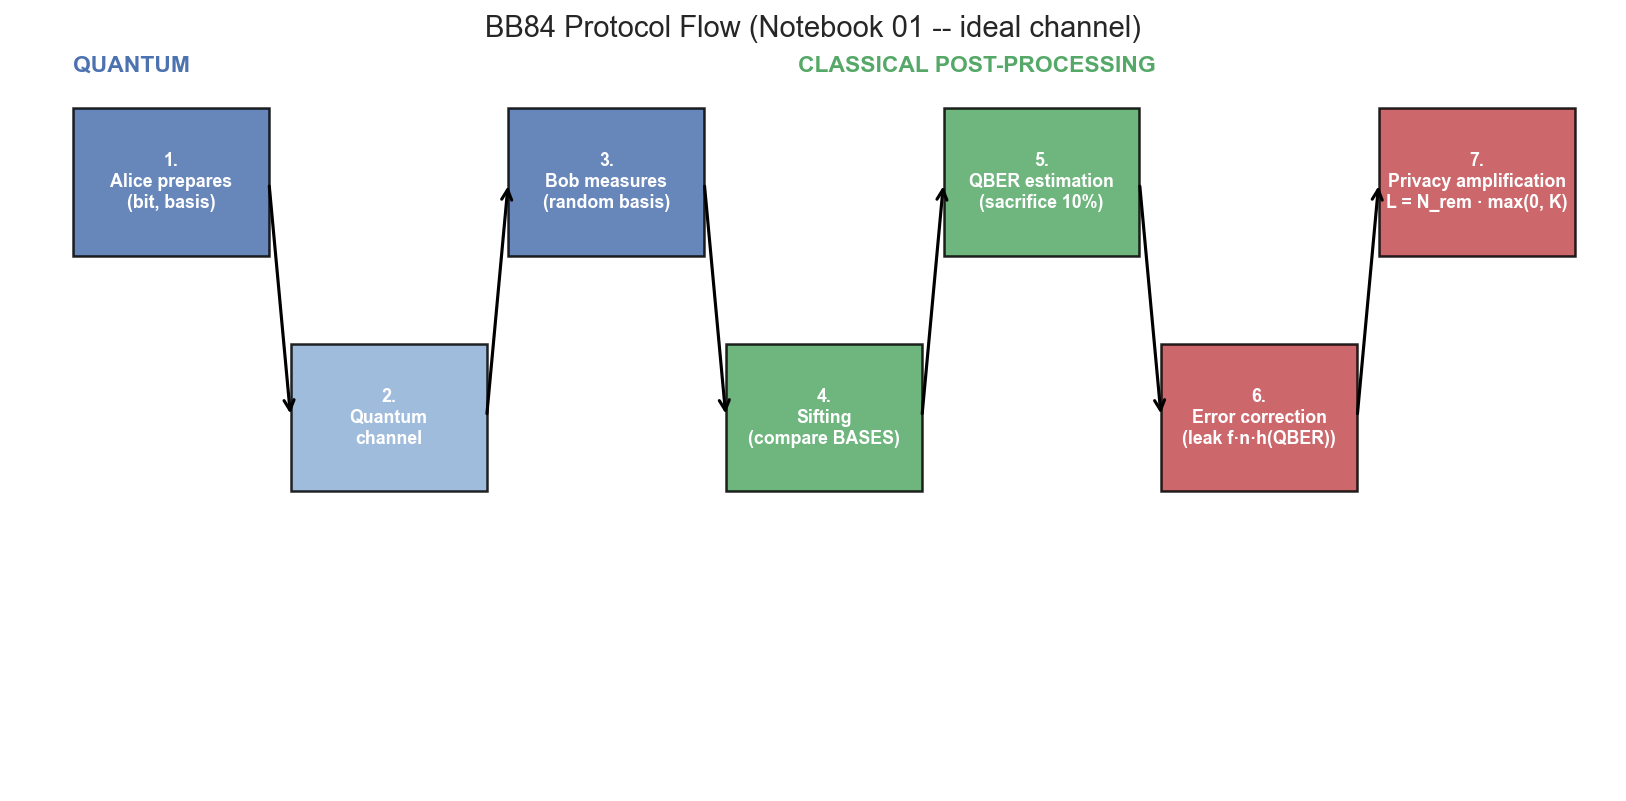

In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.set_xlim(0, 11)
ax.set_ylim(0, 5)
ax.axis('off')

stages = [
    (1, 'Alice prepares\n(bit, basis)', '#4C72B0'),
    (2, 'Quantum\nchannel', '#8FB1D8'),
    (3, 'Bob measures\n(random basis)', '#4C72B0'),
    (4, 'Sifting\n(compare BASES)', '#55A868'),
    (5, 'QBER estimation\n(sacrifice 10%)', '#55A868'),
    (6, 'Error correction\n(leak fÂ·nÂ·h(QBER))', '#C44E52'),
    (7, 'Privacy amplification\nL = N_rem Â· max(0, K)', '#C44E52'),
]

box_w, box_h = 1.35, 1.0

for i, (num, label, color) in enumerate(stages):
    x = 0.4 + i * 1.5
    y = 3.6 if i % 2 == 0 else 2.0
    rect = plt.Rectangle(
        (x, y), box_w, box_h,
        facecolor=color, edgecolor='black', linewidth=1.2, alpha=0.85,
    )
    ax.add_patch(rect)
    ax.text(
        x + box_w / 2, y + box_h / 2,
        f'{num}.\n{label}',
        ha='center', va='center', fontsize=8.5, color='white',
        fontweight='bold',
    )
    if i < len(stages) - 1:
        nx_x = 0.4 + (i + 1) * 1.5
        ny = 3.6 if (i + 1) % 2 == 0 else 2.0
        ax.annotate(
            '',
            xy=(nx_x, ny + box_h / 2),
            xytext=(x + box_w, y + box_h / 2),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
        )

ax.text(0.4, 4.85, 'QUANTUM', fontsize=11, fontweight='bold', color='#4C72B0')
ax.text(5.4, 4.85, 'CLASSICAL POST-PROCESSING', fontsize=11, fontweight='bold',
        color='#55A868')

ax.set_title('BB84 Protocol Flow (Notebook 01 -- ideal channel)', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'bb84_protocol_flow.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Run the BB84 simulation

We use a fixed seed (`2026`) so the entire pipeline &mdash; from Alice's bit string through the disclosed QBER sample &mdash; is reproducible. The notebook runs the full $N = 100\,000$ pipeline for consistency with the Notebook 01 success criterion and the integration test in `tests/test_bb84.py`.

In [4]:
rng = np.random.default_rng(2026)
N_TOTAL = 100_000
F_EC = 1.16

alice_bits, alice_bases = alice_prepare(N_TOTAL, rng=rng)
bob_bases = rng.integers(0, 2, N_TOTAL)
bob_bits = bob_measure(alice_bits, alice_bases, bob_bases, rng=rng)

alice_sifted, bob_sifted = sift(alice_bits, bob_bits, alice_bases, bob_bases)
qber, alice_key, bob_key, sample_idx = estimate_qber(
    alice_sifted, bob_sifted, sample_fraction=0.1, rng=rng
)

corrected_key, leaked_bits = error_correction(alice_key, bob_key, qber, f_ec=F_EC)
L_final = final_key_length(len(alice_key), qber, f_ec=F_EC)

print('=' * 56)
print('BB84 simulation (ideal channel, no Eve)')
print('=' * 56)
print(f'Total bits sent              : {N_TOTAL:>10,}')
print(f'Sifted key length            : {len(alice_sifted):>10,} '
      f'({len(alice_sifted) / N_TOTAL:.1%})')
print(f'QBER sample size (10%)       : {len(sample_idx):>10,}')
print(f'Estimated QBER               : {qber:>10.6f}')
print(f'Remaining key (post-sample)  : {len(alice_key):>10,}')
print(f'EC leakage (f_ec={F_EC})       : {leaked_bits:>10.4f} bits')
print(f'Final secure key length      : {L_final:>10,}')
print(f'Final key fraction / pulse   : {L_final / N_TOTAL:>10.4f}')
print(f'Alice == Bob (post-correction): {bool(np.array_equal(corrected_key, bob_key))}')
print('=' * 56)


BB84 simulation (ideal channel, no Eve)
Total bits sent              :    100,000
Sifted key length            :     50,164 (50.2%)
QBER sample size (10%)       :      5,016
Estimated QBER               :   0.000000
Remaining key (post-sample)  :     45,148
EC leakage (f_ec=1.16)       :     0.0000 bits
Final secure key length      :     45,148
Final key fraction / pulse   :     0.4515
Alice == Bob (post-correction): True


### Sanity checks

On an ideal channel the simulation must satisfy: sift rate $\approx 50\%$, $\mathrm{QBER}=0$, EC leakage $=0$, and $L_{\text{final}}=N_{\text{remaining}}$.